FINITE HORIZON BELLMAN
Solving period 7
Solving period 6
Solving period 5
Solving period 4
Solving period 3
Solving period 2
Solving period 1
Solving period 0

MONTE CARLO POLICY SEARCH
Gamma=0.50 -> avg cost=348432.51
Gamma=0.60 -> avg cost=192372.98
Gamma=0.70 -> avg cost=84777.78
Gamma=0.80 -> avg cost=16507.38
Gamma=0.90 -> avg cost=6823.28
Gamma=1.00 -> avg cost=14938.95
------------------------------------------------------------
BEST MC POLICY: 0.90
BEST AVG COST: 6823.28

TOTAL COSTS FOR ONE WEEK
Bellman             :  3098.00
MC (γ=0.90)         :  7579.00
100%                : 14535.00
90%                 :  6737.00


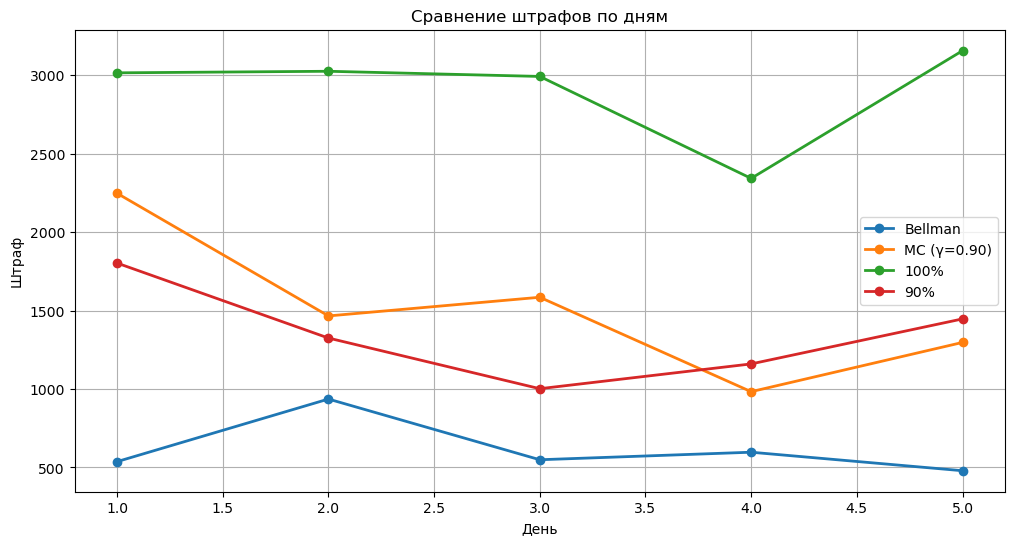

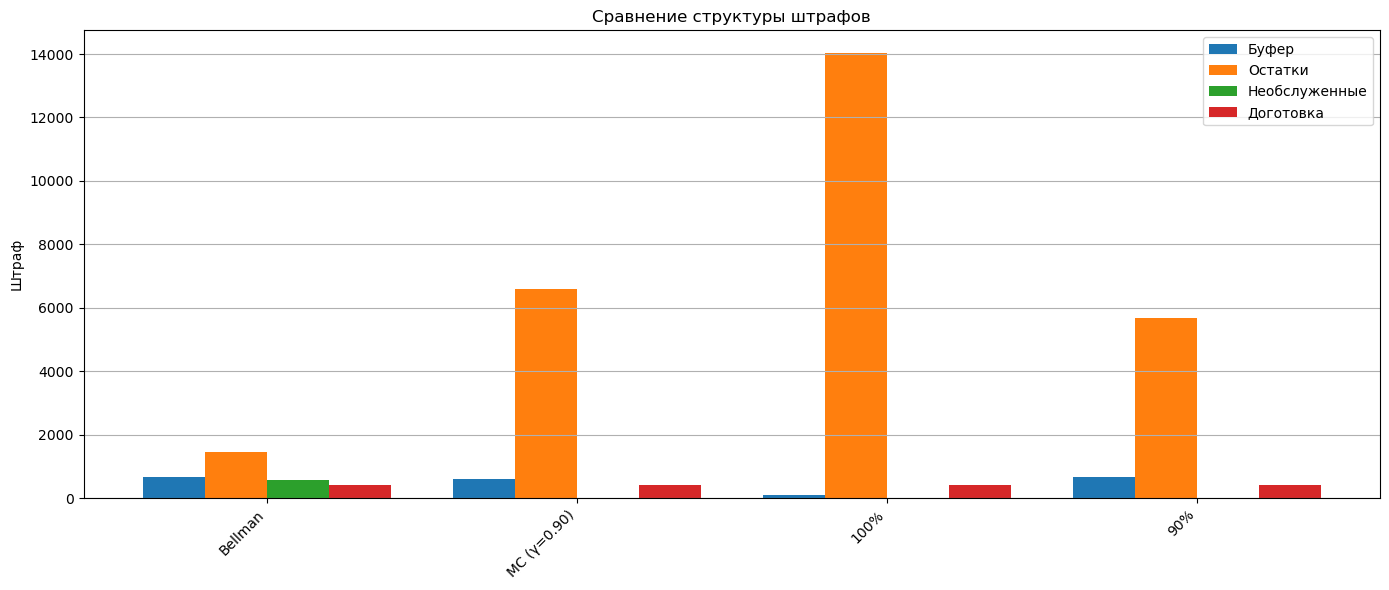

In [27]:
import math
import random
import matplotlib.pyplot as plt

from dataclasses import dataclass


# =====================================================
# CONFIG
# =====================================================

ALPHA = 0.3

LAMBDA_1 = 2.0   # buffer
LAMBDA_2 = 5.0   # leftovers
LAMBDA_3 = 5.0   # unserved
LAMBDA_4 = 1.0   # emergency cooking

MC_SAMPLES = 10

MC_POLICY_WEEKS = 200

OVERBOOKING_LEVELS = [0.85, 0.90, 0.95, 1.00]

FIXED_COOK = 10

plt.rcParams['font.family'] = 'DejaVu Sans'


# =====================================================
# DATA
# =====================================================

TIME_PERIODS = [

    {
        "period": 0,
        "meal_type": "meal_1",
        "groups": "1,2 классы",
        "benefit_students": 100
    },

    {
        "period": 1,
        "meal_type": "meal_1",
        "groups": "3,4,5 классы",
        "benefit_students": 128
    },

    {
        "period": 2,
        "meal_type": "meal_1",
        "groups": "6-9 классы",
        "benefit_students": 112
    },

    {
        "period": 3,
        "meal_type": "meal_2",
        "groups": "1 класс",
        "benefit_students": 28
    },

    {
        "period": 4,
        "meal_type": "meal_2",
        "groups": "2-3 классы",
        "benefit_students": 56
    },

    {
        "period": 5,
        "meal_type": "meal_2",
        "groups": "4-8 классы",
        "benefit_students": 112
    },

    {
        "period": 6,
        "meal_type": "meal_2",
        "groups": "7,9 классы",
        "benefit_students": 56
    },

    {
        "period": 7,
        "meal_type": "meal_2",
        "groups": "полный день",
        "benefit_students": 112
    },
]

T = len(TIME_PERIODS)


# =====================================================
# STATE
# =====================================================

@dataclass(frozen=True)
class State:

    period: int
    lambda_p: int
    buffer: int


@dataclass(frozen=True)
class Action:

    gamma_b: float
    gamma_p: float


# =====================================================
# ACTION SPACE
# =====================================================

ALL_ACTIONS = []

for gb in OVERBOOKING_LEVELS:
    for gp in OVERBOOKING_LEVELS:

        ALL_ACTIONS.append(
            Action(
                gamma_b=gb,
                gamma_p=gp
            )
        )


# =====================================================
# DEMAND
# =====================================================

def sample_absences(b_i):

    d_max = max(1, int(0.15 * b_i))

    weights = [
        (d_max - d + 1) ** 2
        for d in range(d_max + 1)
    ]

    return random.choices(
        list(range(d_max + 1)),
        weights=weights,
        k=1
    )[0]


def poisson_sample(lmbd):

    L = math.exp(-lmbd)

    k = 0
    p = 1

    while p > L:

        k += 1
        p *= random.random()

    return k - 1


def sample_paid(lambda_i):

    return poisson_sample(lambda_i)


def update_lambda(previous_lambda, actual_paid):

    new_lambda = (
        ALPHA * actual_paid
        + (1 - ALPHA) * previous_lambda
    )

    return round(new_lambda)


# =====================================================
# TRANSITION
# =====================================================

def transition(state, action):

    current_data = TIME_PERIODS[state.period]

    b = current_data["benefit_students"]

    prep_b = round(b * action.gamma_b)

    prep_p = round(state.lambda_p * action.gamma_p)

    planned = prep_b + prep_p

    d = sample_absences(b)

    w = sample_paid(state.lambda_p)

    actual_benefit = b - d

    actual = actual_benefit + w

    available = (
        planned
        + state.buffer
        + FIXED_COOK
    )

    served = min(actual, available)

    unserved = max(0, actual - available)

    used_buffer = min(
        state.buffer,
        max(0, actual - planned)
    )

    leftovers = max(0, available - actual)

    next_period = min(
        state.period + 1,
        T - 1
    )

    next_lambda = update_lambda(
        state.lambda_p,
        w
    )

    next_buffer = min(
        80,
        leftovers
    )

    next_state = State(
        period=next_period,
        lambda_p=next_lambda,
        buffer=next_buffer
    )

    cost = (
        LAMBDA_1 * used_buffer
        + LAMBDA_2 * leftovers
        + LAMBDA_3 * (unserved ** 2)
        + LAMBDA_4 * FIXED_COOK
    )

    info = {

        "planned": planned,
        "actual": actual,

        "served": served,
        "unserved": unserved,

        "leftovers": leftovers,
        "used_buffer": used_buffer,

        "buffer_cost":
            LAMBDA_1 * used_buffer,

        "leftovers_cost":
            LAMBDA_2 * leftovers,

        "unserved_cost":
            LAMBDA_3 * (unserved ** 2),

        "cook_cost":
            LAMBDA_4 * FIXED_COOK,

        "cost": cost,

        "gamma_b": action.gamma_b,
        "gamma_p": action.gamma_p,
    }

    return next_state, cost, info


# =====================================================
# STATE SPACE
# =====================================================

ALL_STATES = []

for period in range(T):

    for lambda_p in range(0, 41, 5):

        for buffer in range(0, 81, 10):

            ALL_STATES.append(
                State(
                    period=period,
                    lambda_p=lambda_p,
                    buffer=buffer
                )
            )


# =====================================================
# BELLMAN TABLES
# =====================================================

V = {}
POLICY = {}


# =====================================================
# BELLMAN
# =====================================================

def solve_bellman():

    for state in ALL_STATES:

        V[(T, state)] = 0

    for t in reversed(range(T)):

        print(f"Solving period {t}")

        current_states = [
            s for s in ALL_STATES
            if s.period == t
        ]

        for state in current_states:

            best_value = float("inf")

            best_action = None

            for action in ALL_ACTIONS:

                total = 0

                for _ in range(MC_SAMPLES):

                    next_state, cost, _ = transition(
                        state,
                        action
                    )

                    if t == T - 1:

                        future = 0

                    else:

                        future = V.get(
                            (t + 1, next_state),
                            0
                        )

                    total += (
                        cost + future
                    )

                expected = total / MC_SAMPLES

                if expected < best_value:

                    best_value = expected

                    best_action = action

            V[(t, state)] = best_value

            POLICY[(t, state)] = best_action


# =====================================================
# POLICIES
# =====================================================

def optimal_policy(state):

    approx_state = State(
        period=state.period,
        lambda_p=5 * round(state.lambda_p / 5),
        buffer=10 * round(state.buffer / 10)
    )

    return POLICY.get(
        (state.period, approx_state),
        Action(1.0, 1.0)
    )


def fixed_policy(level):

    return Action(
        gamma_b=level,
        gamma_p=level
    )


# =====================================================
# SIMULATION
# =====================================================

def simulate_week(mode="optimal", fixed_level=1.0):

    results = []

    state = State(
        period=0,
        lambda_p=20,
        buffer=20
    )

    cumulative_cost = 0

    for day in range(5):

        for period in range(T):

            # =====================================
            # POLICY
            # =====================================

            if mode == "optimal":

                action = optimal_policy(state)

            else:

                action = fixed_policy(fixed_level)

            # =====================================
            # TRANSITION
            # =====================================

            next_state, cost, info = transition(
                state,
                action
            )

            cumulative_cost += cost

            results.append({

                "day": day + 1,
                "period": period,

                "buffer_cost":
                    info["buffer_cost"],

                "leftovers_cost":
                    info["leftovers_cost"],

                "unserved_cost":
                    info["unserved_cost"],

                "cook_cost":
                    info["cook_cost"],

                "cost": cost
            })

            state = next_state

        state = State(
            period=0,
            lambda_p=state.lambda_p,
            buffer=20
        )

    return results


# =====================================================
# MONTE CARLO POLICY SEARCH
# =====================================================

def monte_carlo_search():

    candidate_levels = [
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
        1.00
    ]

    best_gamma = None

    best_cost = float("inf")

    print("\n" + "=" * 60)
    print("MONTE CARLO POLICY SEARCH")
    print("=" * 60)

    for gamma in candidate_levels:

        total_cost = 0

        for _ in range(MC_POLICY_WEEKS):

            results = simulate_week(
                mode="fixed",
                fixed_level=gamma
            )

            week_cost = sum(
                r["cost"]
                for r in results
            )

            total_cost += week_cost

        avg_cost = (
            total_cost
            / MC_POLICY_WEEKS
        )

        print(
            f"Gamma={gamma:.2f} "
            f"-> avg cost={avg_cost:.2f}"
        )

        if avg_cost < best_cost:

            best_cost = avg_cost

            best_gamma = gamma

    print("-" * 60)

    print(
        f"BEST MC POLICY: "
        f"{best_gamma:.2f}"
    )

    print(
        f"BEST AVG COST: "
        f"{best_cost:.2f}"
    )

    print("=" * 60)

    return best_gamma


# =====================================================
# DAILY COSTS
# =====================================================

def get_daily_costs(results):

    daily = []

    for day in range(1, 6):

        total = sum(
            r["cost"]
            for r in results
            if r["day"] == day
        )

        daily.append(total)

    return daily


# =====================================================
# COST STRUCTURE
# =====================================================

def get_cost_structure(results):

    return {

        "buffer":
            sum(r["buffer_cost"] for r in results),

        "leftovers":
            sum(r["leftovers_cost"] for r in results),

        "unserved":
            sum(r["unserved_cost"] for r in results),

        "cook":
            sum(r["cook_cost"] for r in results),
    }


# =====================================================
# PLOTS
# =====================================================

def plot_all_graphs(results_dict):

    days = [1, 2, 3, 4, 5]

    # =================================================
    # GRAPH 1 - Daily costs comparison
    # =================================================

    plt.figure(figsize=(12, 6))

    for label, results in results_dict.items():

        daily = get_daily_costs(results)

        plt.plot(
            days,
            daily,
            marker='o',
            linewidth=2,
            label=label
        )

    plt.xlabel("День")

    plt.ylabel("Штраф")

    plt.title("Сравнение штрафов по дням")

    plt.legend()

    plt.grid(True)

    plt.show()

    # =================================================
    # GRAPH 2 - Cost structure comparison
    # =================================================

    policies = list(results_dict.keys())

    buffer_values = []
    leftovers_values = []
    unserved_values = []
    cook_values = []

    for policy_name in policies:

        structure = get_cost_structure(
            results_dict[policy_name]
        )

        buffer_values.append(
            structure["buffer"]
        )

        leftovers_values.append(
            structure["leftovers"]
        )

        unserved_values.append(
            structure["unserved"]
        )

        cook_values.append(
            structure["cook"]
        )

    x = range(len(policies))

    width = 0.2

    plt.figure(figsize=(14, 6))

    plt.bar(
        [i - 1.5 * width for i in x],
        buffer_values,
        width=width,
        label="Буфер"
    )

    plt.bar(
        [i - 0.5 * width for i in x],
        leftovers_values,
        width=width,
        label="Остатки"
    )

    plt.bar(
        [i + 0.5 * width for i in x],
        unserved_values,
        width=width,
        label="Необслуженные"
    )

    plt.bar(
        [i + 1.5 * width for i in x],
        cook_values,
        width=width,
        label="Доготовка"
    )

    plt.xticks(x, policies, rotation=45, ha='right')

    plt.ylabel("Штраф")

    plt.title(
        "Сравнение структуры штрафов"
    )

    plt.legend()

    plt.grid(True, axis='y')

    plt.tight_layout()
    
    plt.show()


# =====================================================
# MAIN
# =====================================================

def main():

    random.seed(42)

    print("=" * 60)
    print("FINITE HORIZON BELLMAN")
    print("=" * 60)

    solve_bellman()

    best_mc_gamma = monte_carlo_search()

    # =================================================
    # SIMULATIONS
    # =================================================

    results_dict = {

        "Bellman":
            simulate_week(mode="optimal"),

        f"MC (γ={best_mc_gamma:.2f})":
            simulate_week(
                mode="fixed",
                fixed_level=best_mc_gamma
            ),

        "100%":
            simulate_week(
                mode="fixed",
                fixed_level=1.0
            ),

        "90%":
            simulate_week(
                mode="fixed",
                fixed_level=0.9
            ),



    }

    # =================================================
    # TOTAL COSTS
    # =================================================

    print("\n" + "=" * 60)
    print("TOTAL COSTS FOR ONE WEEK")
    print("=" * 60)

    for label, results in results_dict.items():

        total = sum(
            r["cost"]
            for r in results
        )

        print(f"{label:20}: {total:8.2f}")

    print("=" * 60)

    # =================================================
    # PLOTS
    # =================================================

    plot_all_graphs(results_dict)


if __name__ == "__main__":

    main()